# GP-PHS: DC Motor with Elastic Load

This example models a simple DC motor connected to a load through a spring. The system has **three states**:

- $\phi$ – magnetic flux (electrical energy)
- $q$ – spring deflection
- $p$ – load momentum

The total stored energy (Hamiltonian) is

$$
H(\phi,q,p)
=
\frac{\phi^2}{2L}
+
\frac{kq^2}{2}
+
\frac{p^2}{2J_m},
$$

where $L$ is the inductance, $k$ is the spring stiffness, and $J_m$ is the load inertia.

## Port-Hamiltonian Model

The system dynamics are

$$
\dot{x} = (J - R)\nabla H(x) + Gu,
$$

where:

### Interconnection Matrix

The matrix $J$ describes how energy flows between the electrical and mechanical parts of the system:

$$
J =
\begin{bmatrix}
0 & 0 & -k_t \\
0 & 0 & 1 \\
k_t & -1 & 0
\end{bmatrix}.
$$

### Dissipation Matrix

The matrix $R$ models energy losses due to electrical resistance and mechanical damping:

$$
R =
\begin{bmatrix}
r_a & 0 & 0 \\
0 & 0 & 0 \\
0 & 0 & b
\end{bmatrix}.
$$

### Input Matrix

The input voltage acts only on the electrical state:

$$
G =
\begin{bmatrix}
1 \\
0 \\
0
\end{bmatrix}.
$$

## Parameters to Learn

In this example, the GP-PHS model learns three physical parameters:

$$
\theta = \{k_t,\; r_a,\; b\},
$$

corresponding to the motor constant, armature resistance, and mechanical damping.

### Install (Colab only)
Skip this step when running locally.

In [1]:
# ── Google Colab / fresh environment setup ──────────────────────────────────
# !pip install -q git+https://github.com/essey1/neuromancer.git gpytorch scipy

## Imports

In [2]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parents[1] / "src"))

import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import gpytorch
from scipy.integrate import odeint
from torch.utils.data import DataLoader

from neuromancer import psl
from neuromancer import dataset
import neuromancer.dataset as dataset
from neuromancer.psl import plot
from neuromancer.dynamics import gp_phs, ode
from neuromancer.psl import gp_smoother
from neuromancer.modules import hamiltonian_approximator
from neuromancer.system import Node, System
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.loss import AugmentedLagrangeLoss
from neuromancer.problem import Problem
from neuromancer.trainer import Trainer
from neuromancer.loggers import BasicLogger

torch.manual_seed(0); np.random.seed(0)

## Configuration

In [3]:
# DATA & TRAINING HYPERPARAMETERS
N_POINTS = 150        # per trajectory; total = N_POINTS * len(X0_TRAIN)
NOISE    = 0.01        # sensor noise std
N_EPOCHS = 2000
NX, NU   = 3, 1         # NU=1: single voltage input, drives flux state only
T_SIM    = 5.0       # simulation time for training data generation

X0_TRAIN = [
    # Single-state excitations
    [1.0, 0.0, 0.0],    # electrical
    [0.0, 1.0, 0.0],    # spring
    [0.0, 0.0, 1.0],    # momentum

    # Cross-domain coupling
    [1.0, 0.0, 1.0],    # electrical + momentum (k_t)

    # Full-state excitation
    [1.0, 1.0, 1.0],    # all states active
]

X0_TEST = [
    [0.9, 0.1, 0.1],    # near electrical excitation
    [0.1, 0.9, 0.9],    # spring + momentum coupling
    [1.1, 1.1, 1.1],    # higher-energy
]

# True system parameters
L_TRUE  = 0.5     # armature inductance
K_TRUE  = 2.0     # spring stiffness
JM_TRUE = 0.1     # load inertia

# Dissipation
RA_TRUE = 1.0     # armature resistance
B_TRUE  = 0.05    # mechanical damping

# Electromechanical coupling
KT_TRUE = 0.5     # motor torque / back-EMF constant

# Input signal
INPUT_AMP    = 2.0
INPUT_FREQ_A = 3.0
INPUT_FREQ_B = 7.0

## True System

In [4]:
# Define true system parameters
true_params = {
    'L': L_TRUE, 'k': K_TRUE, 'Jm': JM_TRUE,
    'kt': KT_TRUE, 'ra': RA_TRUE, 'b': B_TRUE
}

def H_true(phi, q, p):
    """Hamiltonian energy"""
    return phi**2 / (2*L_TRUE) + 0.5*K_TRUE*q**2 + p**2 / (2*JM_TRUE)

def grad_H_true(state):
    """Gradient of Hamiltonian"""
    phi, q, p = state
    return np.array([phi/L_TRUE, K_TRUE*q, p/JM_TRUE])

def J_true(state):
    """Skew-symmetric interconnection matrix J (constant)"""
    return np.array([
        [0,       0,      -KT_TRUE],
        [0,       0,       1      ],
        [KT_TRUE, -1,      0      ]
    ])

def R_true(state):
    """Dissipation matrix R [diagonal, constant]"""
    return np.diag([
        RA_TRUE,
        0.0,
        B_TRUE
    ])

def G_mat_true(state):
    """Input matrix G (constant)"""
    return np.array([
        [1.0],
        [0.0],
        [0.0]
    ])

def input_signal(t):
    """Time-dependent input signal u(t)"""
    u1 = INPUT_AMP * np.sin(INPUT_FREQ_A * t) + 1.0 * np.sin(INPUT_FREQ_B * t)
    return np.array([u1])

def dynamics(state, t, sig=input_signal):
    """Complete PHS dynamics: ẋ = (J-R)∇H + Gu"""
    grad_h = grad_H_true(state)
    J = J_true(state)
    R = R_true(state)
    G = G_mat_true(state)
    u = sig(t)
    return (J - R) @ grad_h + G @ u

### Plot

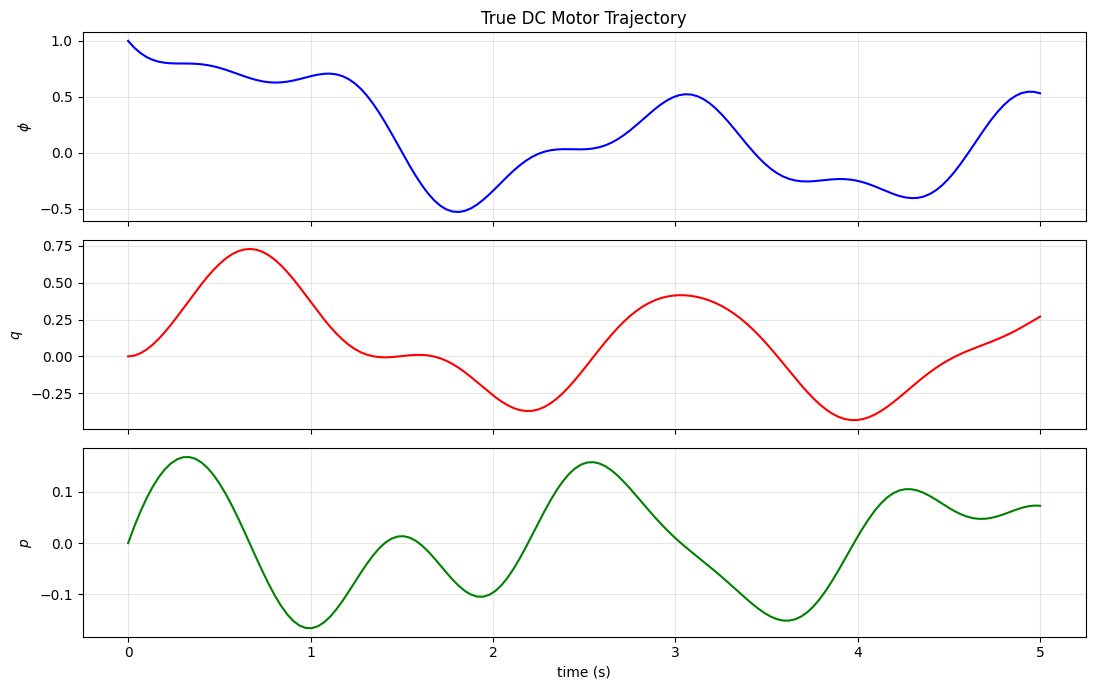

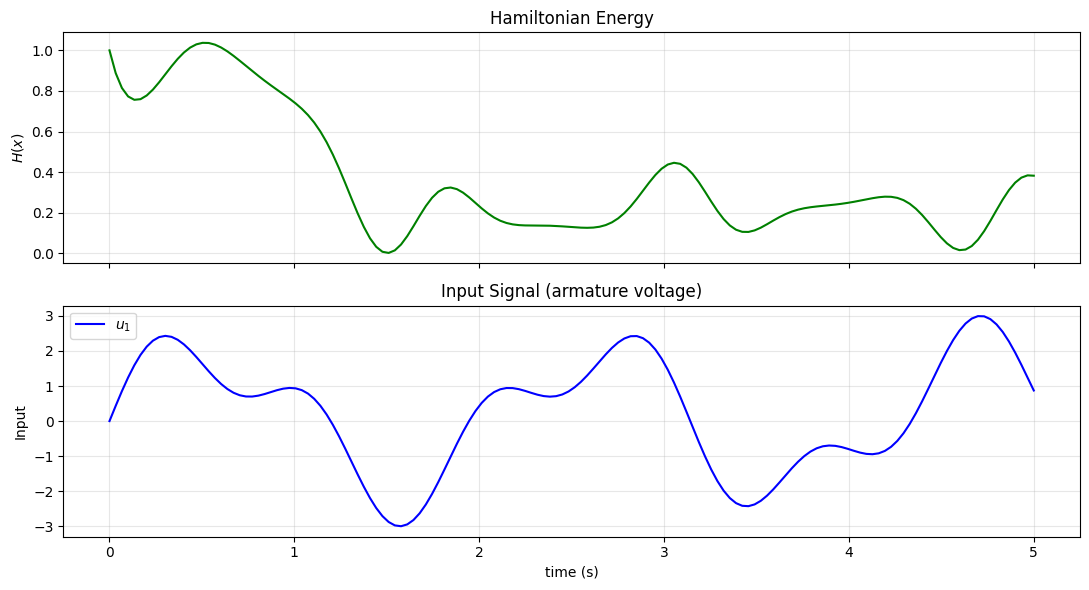

In [5]:
# Plot the mixed-excitation trajectory
x0  = X0_TRAIN[0]
t_i = np.linspace(0, T_SIM, N_POINTS)
traj_i = odeint(lambda state, t, s=input_signal: dynamics(state, t, s), x0, t_i)
u_i    = np.array([input_signal(t) for t in t_i])
H_i    = np.array([H_true(x[0], x[1], x[2]) for x in traj_i])

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
labels = [r'$\phi$', r'$q$', r'$p$']
colors = ['b', 'r', 'g']
for j, (ax, lbl, col) in enumerate(zip(axes, labels, colors)):
    ax.plot(t_i, traj_i[:, j], col, lw=1.5)
    ax.set_ylabel(lbl); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('time (s)')
axes[0].set_title('True DC Motor Trajectory')
plt.tight_layout(); plt.show()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax1.plot(t_i, H_i, 'g', lw=1.5)
ax1.set_ylabel(r'$H(x)$'); ax1.grid(True, alpha=0.3)
ax1.set_title('Hamiltonian Energy')
ax2.plot(t_i, u_i[:, 0], 'b', label=r'$u_1$', lw=1.5)
ax2.set_ylabel('Input'); ax2.set_xlabel('time (s)'); ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_title('Input Signal (armature voltage)')
plt.tight_layout(); plt.show()

## Step 1: Dataset Preparation

### Data Sampling & Dataset Preparation

In [6]:
# DATA GENERATION
sigs = [input_signal] * len(X0_TRAIN)
trajs_true, trajs, us, t_all = [], [], [], []
for i, (x0, sig) in enumerate(zip(X0_TRAIN, sigs)):
    t_i = np.linspace(i * T_SIM, (i + 1) * T_SIM, N_POINTS)
    x_i = odeint(lambda state, t, s=sig: dynamics(state, t, s), x0, t_i)
    u_i = np.array([sig(t) for t in t_i])
    trajs_true.append(x_i)
    x_noisy_i = x_i + np.random.normal(0, NOISE, x_i.shape)
    trajs.append(x_noisy_i); us.append(u_i); t_all.append(t_i)

# GP SMOOTHER
smoothed, xdots, xdot_vars = [], [], []
for t_i, x_i in zip(t_all, trajs):
    x_s, xd, xdv = gp_smoother.gp_smooth(t_i, x_i)
    smoothed.append(x_s); xdots.append(xd); xdot_vars.append(xdv)

# DATA LOADERS
train_loader, dev_loader, test_loader = dataset.get_gpphs_dataloaders(
    x=np.concatenate(smoothed),
    x_dot=np.concatenate(xdots),
    u=np.concatenate(us),
    x_dot_var=np.concatenate(xdot_vars),
    split_ratio=[75.0, 15.0, 10.0],
    batch_size=len(X0_TRAIN) * N_POINTS,
)

C:\Users\arayae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\_compile.py:54: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)
C:\Users\arayae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gpytorch\models\exact_gp.py:299: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


### Plot

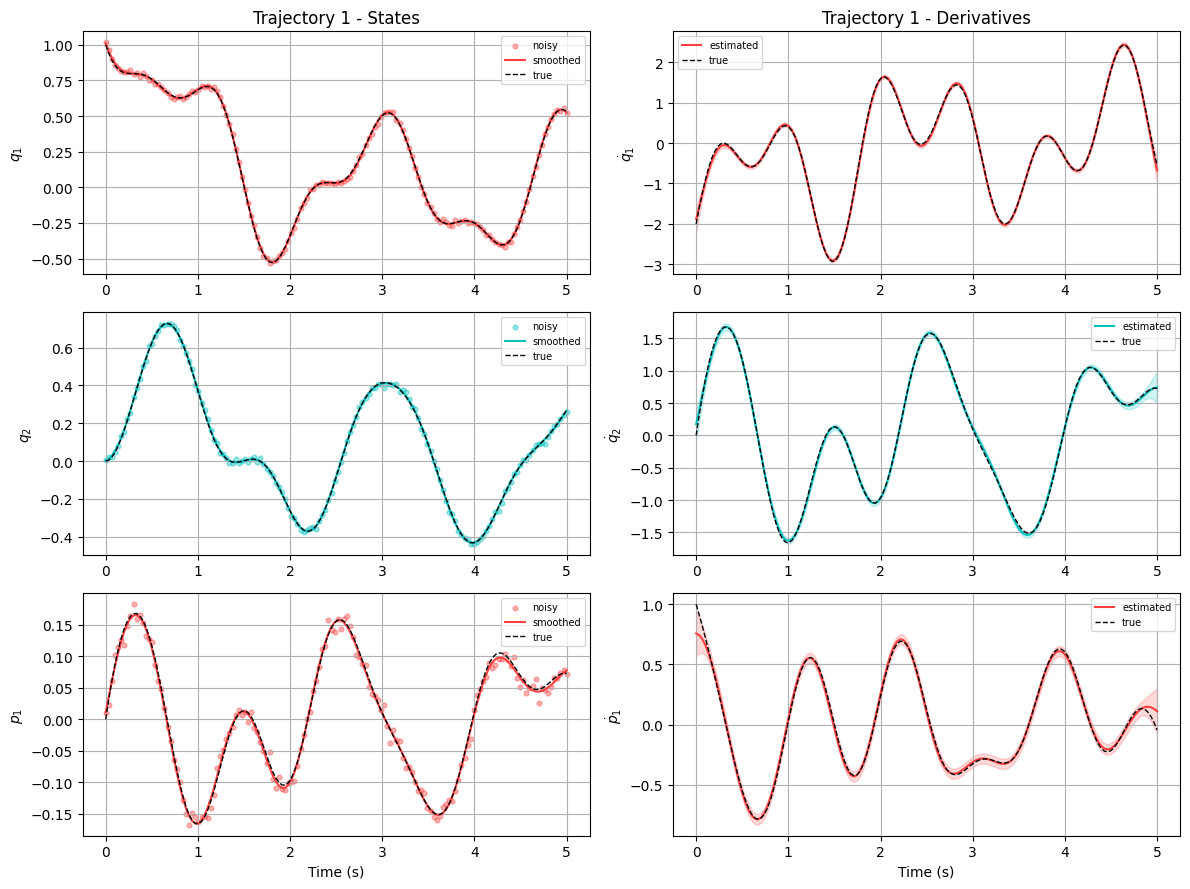

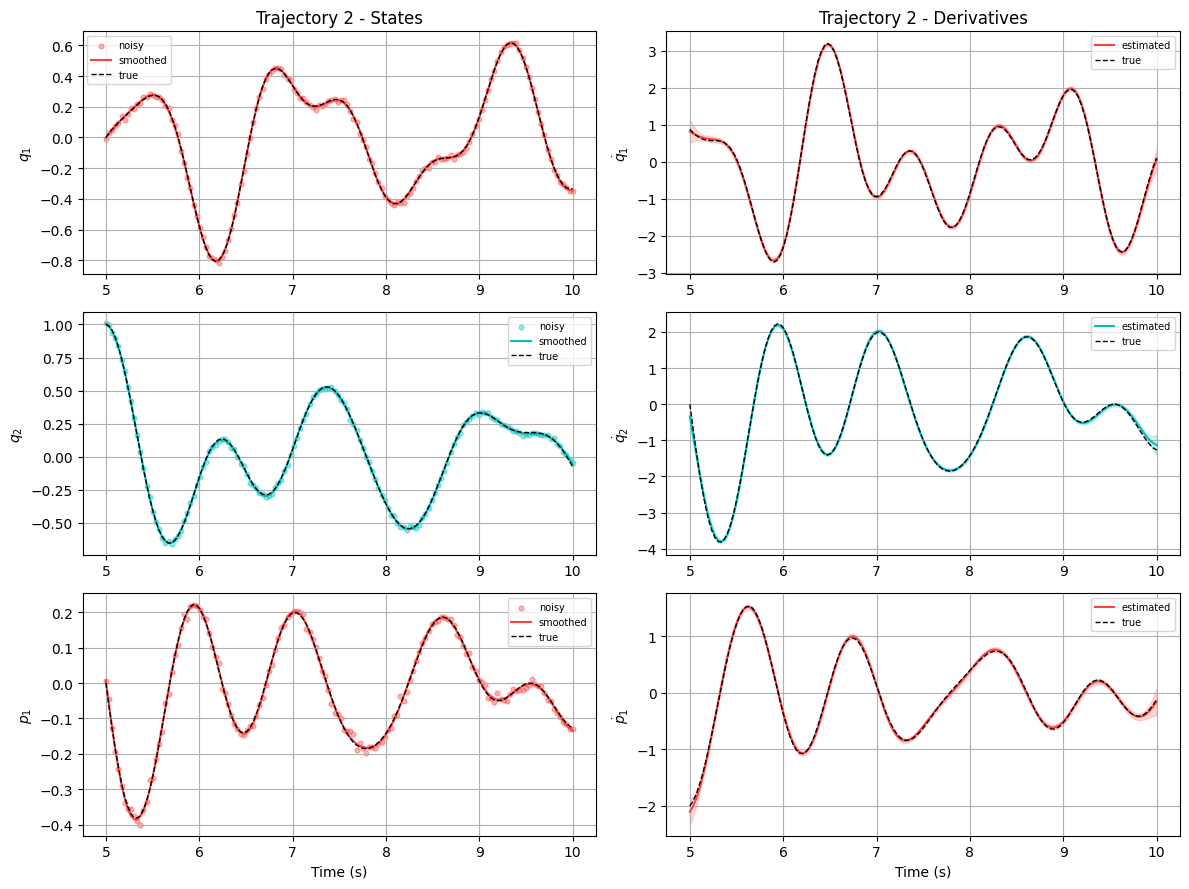

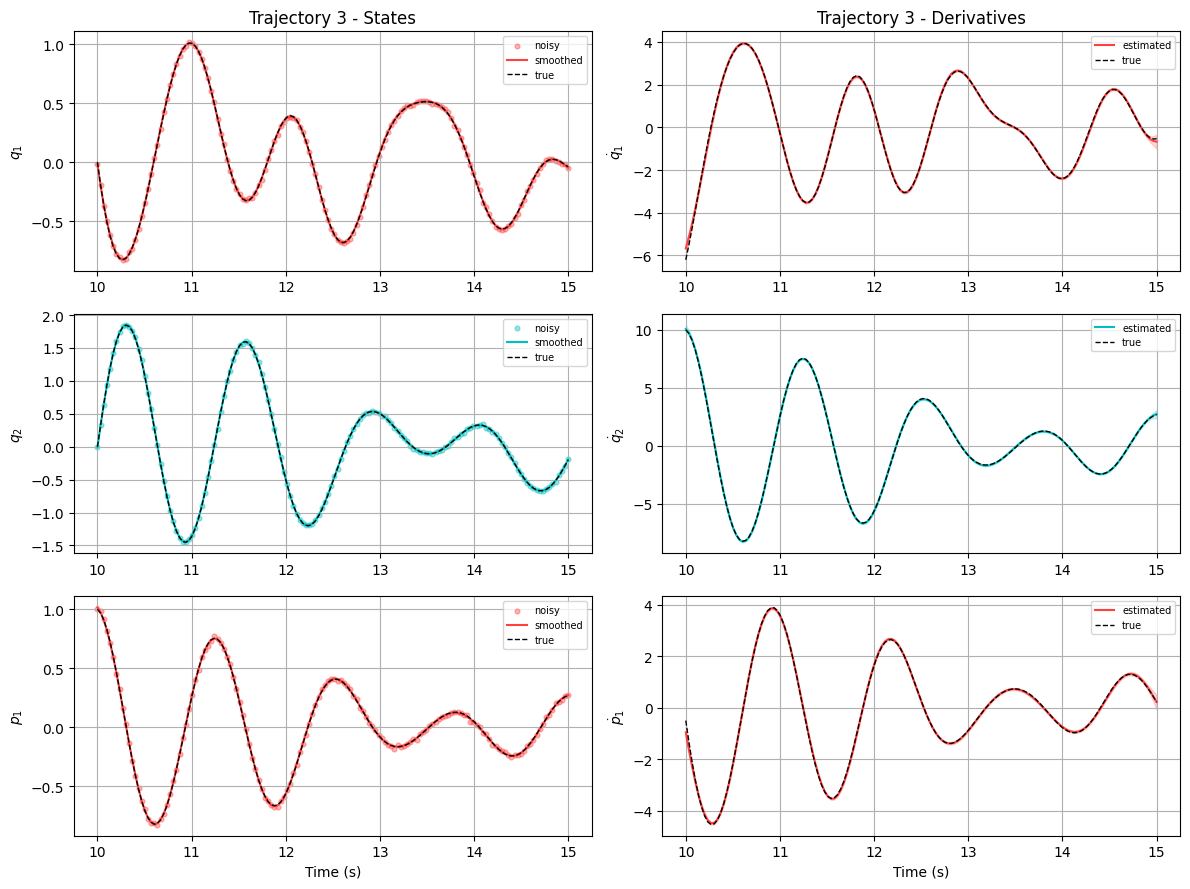

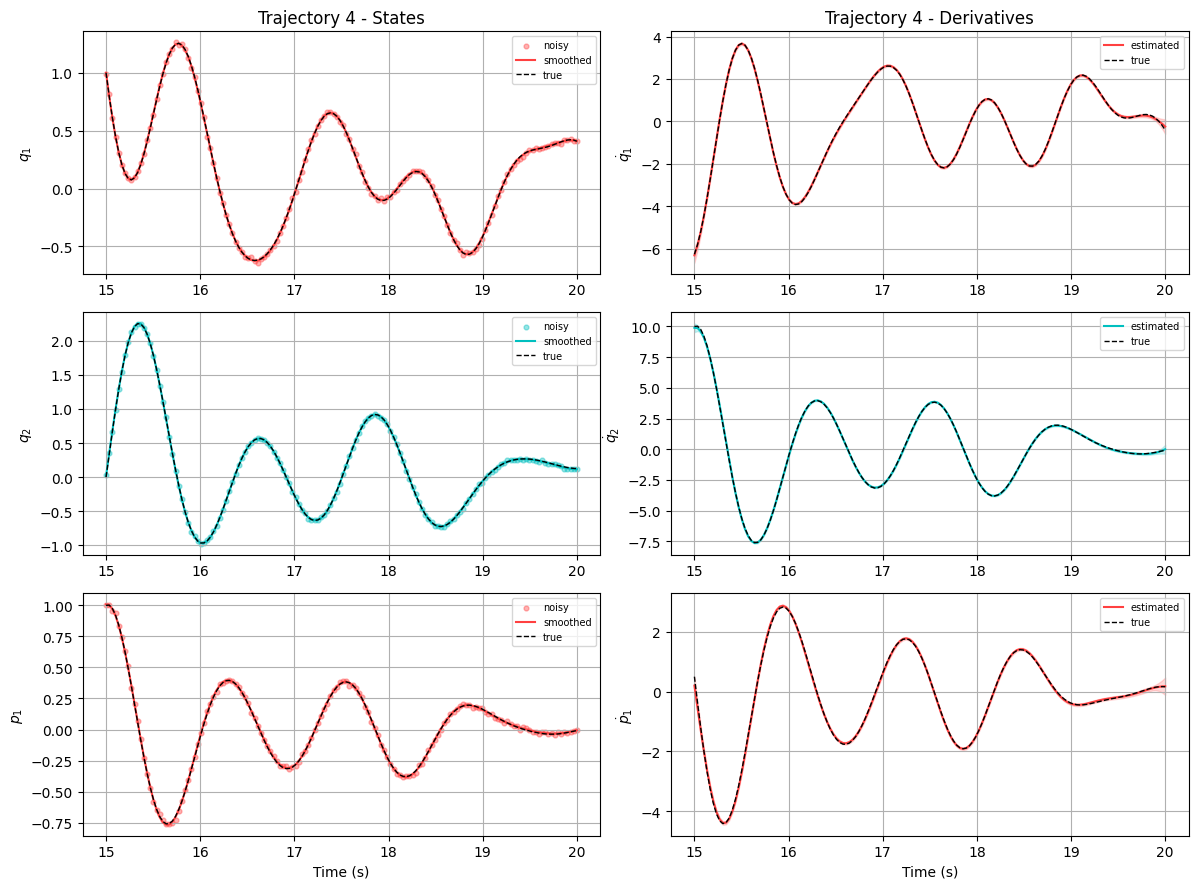

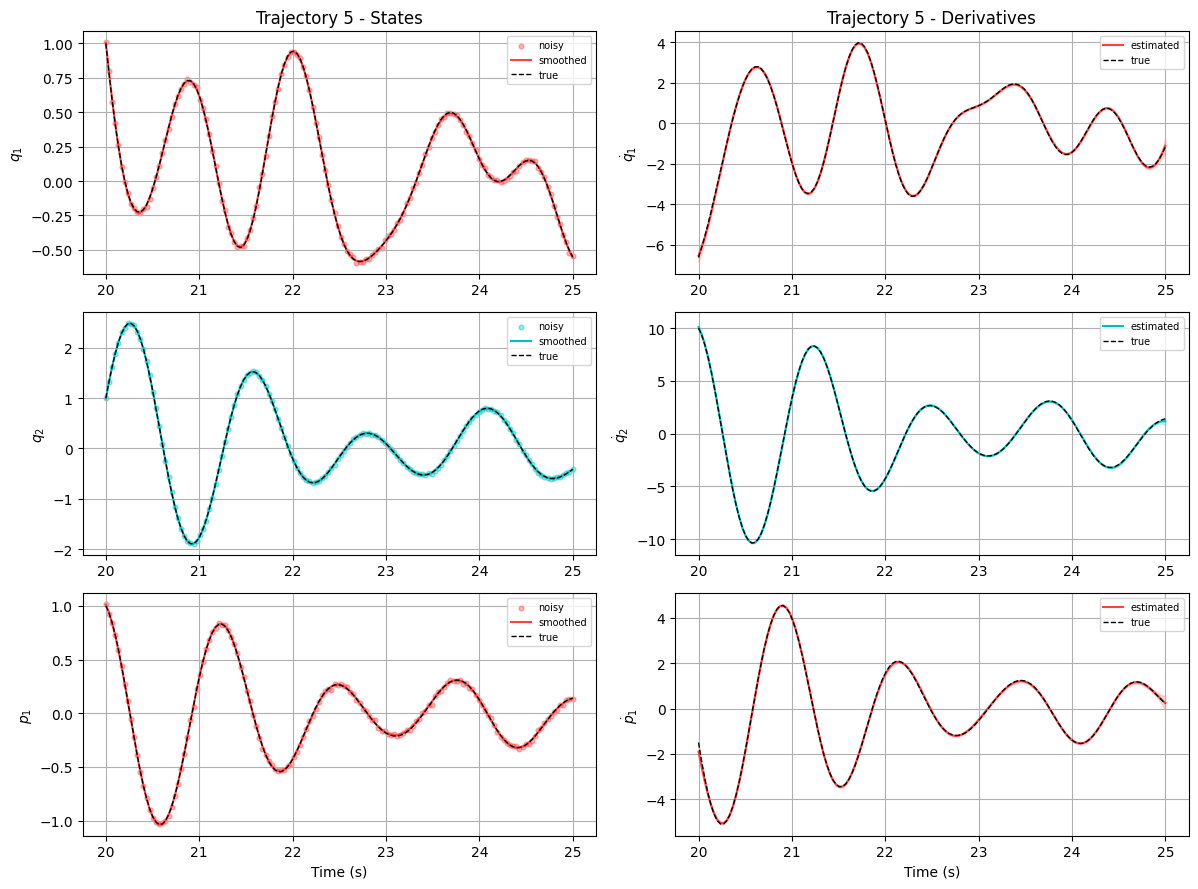

In [7]:
plot.pltGPSmooth(
    t_all,
    trajs,
    smoothed,
    xdots,
    xdot_vars,
    x_trues=trajs_true,
    dynamics=dynamics,
    sigs=sigs,
    state_lbls=[r'$q_1$', r'$q_2$', r'$p_1$', r'$p_2$'],
    deriv_lbls=[r'$\dot{q}_1$', r'$\dot{q}_2$', r'$\dot{p}_1$', r'$\dot{p}_2$'],
)

## Step 2: PHS Structure



In [8]:
kt = variable(torch.tensor([0.1], requires_grad=True), display_name='kt')
ra = variable(torch.tensor([0.1], requires_grad=True), display_name='ra')
b  = variable(torch.tensor([0.1], requires_grad=True), display_name='b')

### Construct PHSMatrices

In [9]:
phs = gp_phs.PHSMatrices(
    nx=NX, nu=NU,
    J_upper = {
        (0, 2): lambda x: -kt.value * torch.ones(x.shape[0]),
        (1, 2): lambda x:  torch.ones(x.shape[0]),
    },
    R_diag={
        0: lambda x: ra.value * torch.ones(x.shape[0]),
        1: lambda x: torch.zeros(x.shape[0]),
        2: lambda x: b.value * torch.ones(x.shape[0])
    },
    G_full={
        (0, 0): lambda x: torch.ones(x.shape[0])
    }
)

## Step 3: Build Node, Loss, and Problem

In [10]:
# Build node
gpphs_module = gp_phs.GPPHSNode(phs, NX, NU)
gpphs_node = Node(gpphs_module, ['X', 'U', 'Xdot', 'Xdot_var'], ['nlml'], name='gp_phs')

# Objective
nlml = variable('nlml')
nlml_loss = nlml.minimize()
nlml_loss.name = 'nlml_loss'

# Aggregate and build problem
objectives  = [nlml_loss]
constraints = []

loss    = PenaltyLoss(objectives, constraints)
problem = Problem([gpphs_node], loss)

## Step 4: Training

In [11]:
optimizer = torch.optim.Adam(problem.parameters(), lr=0.01)
logger    = BasicLogger(args=None, savedir='test', verbosity=1,
                        stdout=['train_loss', 'dev_loss'])
trainer   = Trainer(
    problem,
    train_loader,
    dev_loader,
    optimizer,
    epochs=N_EPOCHS,
    patience=N_EPOCHS,
    epoch_verbose=5,
    train_metric='train_loss',
    dev_metric='dev_loss',
    eval_metric='dev_loss',
    logger=logger,
)

None
Number of parameters: 8


In [12]:
# train
best_model = trainer.train()
problem.load_state_dict(best_model)

epoch: 0	train_loss: 672093.68750	dev_loss: 66413.21094	eltime:  0.28639
epoch: 1	train_loss: 651202.68750	dev_loss: 61279.53125	eltime:  0.46936
epoch: 2	train_loss: 628542.25000	dev_loss: 56536.25781	eltime:  0.66714
epoch: 3	train_loss: 607717.75000	dev_loss: 52093.35156	eltime:  0.85818
epoch: 4	train_loss: 586640.75000	dev_loss: 47973.33203	eltime:  1.05302
epoch: 5	train_loss: 564515.06250	dev_loss: 44192.38672	eltime:  1.24477
epoch: 6	train_loss: 545830.56250	dev_loss: 40663.54688	eltime:  1.43926
epoch: 7	train_loss: 525451.62500	dev_loss: 37392.78125	eltime:  1.62801
epoch: 8	train_loss: 505939.96875	dev_loss: 34368.80469	eltime:  1.81884
epoch: 9	train_loss: 485356.46875	dev_loss: 31580.74805	eltime:  2.01721
epoch: 10	train_loss: 468303.56250	dev_loss: 29014.50000	eltime:  2.20484
epoch: 11	train_loss: 451209.15625	dev_loss: 26657.56445	eltime:  2.40771
epoch: 12	train_loss: 433661.12500	dev_loss: 24480.20508	eltime:  2.60839
epoch: 13	train_loss: 416256.50000	dev_loss: 224

<All keys matched successfully>

### Parameter Recovery

In [13]:
gp_phs.param_table({
    'kₜ': (kt, KT_TRUE),
    'rₐ': (ra, RA_TRUE),
    'b':  (b,  B_TRUE),
})


Parameter  True  Learned  Rel. Error %
       kₜ  0.50 0.503917      0.783323
       rₐ  1.00 0.988148      1.185195
        b  0.05 0.050043      0.086486

Mean relative error:   0.69%
Median relative error: 0.78%


,Parameter,True,Learned,Rel. Error %
0,kₜ,0.50,0.503917,0.783323
1,rₐ,1.00,0.988148,1.185195
2,b,0.05,0.050043,0.086486


## Step 5: Hamiltonian Posterior

$H$ is identifiable up to an additive constant; the posterior mean is aligned to the true $H$ at training points.

In [14]:
# BUILD GP POSTERIOR
posterior = gpphs_node.callable.posterior()

# COMPUTE HAMILTONIAN POSTERIOR — all trajectories
H_mean, H_var, H_samples = posterior.predict(
    smoothed,
    us,
    xdots,
    xdot_vars,
    n_samples=50,
)

# Concatenate all trajectories for evaluation
x_all      = np.concatenate(smoothed, axis=0)
u_all      = np.concatenate(us, axis=0)
xdot_true  = np.concatenate(xdots, axis=0)
x_all_t    = torch.tensor(x_all, dtype=torch.float32)

# TRUE HAMILTONIAN — all trajectories
H_true_all = np.array([H_true(*row) for row in x_all])

### Plot

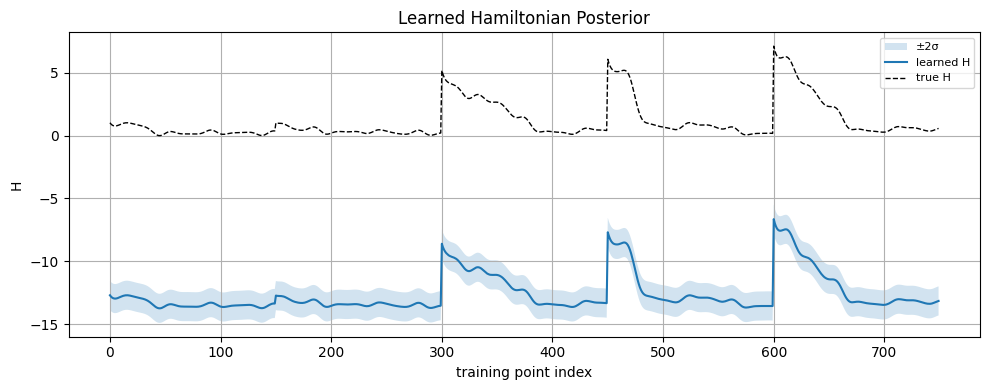

In [15]:
plot.pltHamiltonian(H_mean.numpy(), H_var.numpy(), H_true=H_true_all)

## Step 6: Callable $H^*$ Ensemble

Fit a GP interpolant to each posterior sample so $H^*$ can be evaluated and differentiated anywhere.

In [16]:
ensemble = [
    hamiltonian_approximator.HamiltonianApproximator(
        method='gp',
        lengthscale=posterior.lengthscale,
        signal_var=posterior.signal_var,
    ).fit(x_all_t, H_samples[i])
    for i in range(H_samples.shape[0])
]

## Step 7: Derivative Prediction

Verify that the learned model predicts $\dot{x} = (J(x) - R(x))\nabla H^*(x)$ correctly at training points before committing to full trajectory rollout.

In [17]:
# EVALUATE LEARNED DYNAMICS: ẋ = (J(x) - R(x))∇H*(x) + G(x)u
JR            = (phs.get_J(x_all_t) - phs.get_R(x_all_t)).detach().numpy()
G             = phs.get_G(x_all_t).detach().numpy()
grad_H_stack  = torch.stack([h.gradient(x_all_t) for h in ensemble])
grad_H_mean   = grad_H_stack.mean(0).detach().numpy()
grad_H_std    = grad_H_stack.std(0).detach().numpy()
xdot_pred     = np.einsum('nij,nj->ni', JR, grad_H_mean) + np.einsum('nij,nj->ni', G, u_all)
xdot_pred_std = np.einsum('nij,nj->ni', JR, grad_H_std)

### Plot

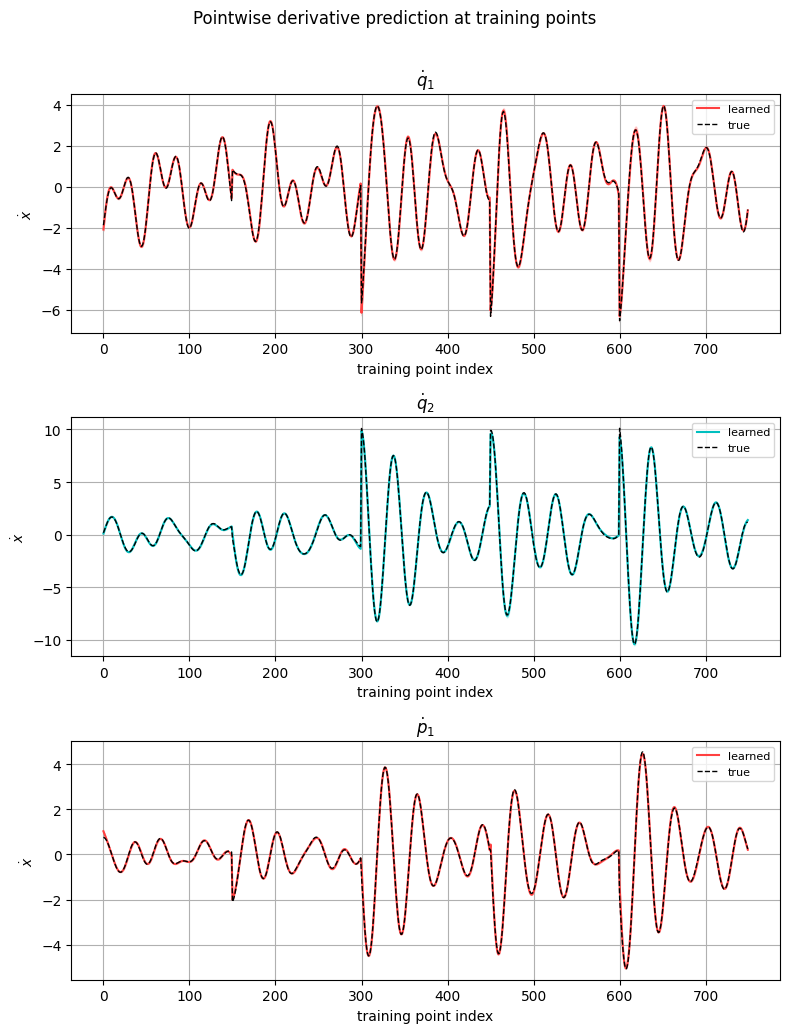

In [18]:
plot.pltXdot(
    xdot_pred, xdot_true,
    xdot_std=xdot_pred_std,
    state_lbls=[r'$\dot{q}_1$', r'$\dot{q}_2$', r'$\dot{p}_1$', r'$\dot{p}_2$'],
)

## Step 8: Trajectory Prediction

Simulate 10 trajectories (one per $H^*$ sample). Shaded band = $\pm 2$ std across the ensemble.

In [19]:
dt    = 0.005
t_sim = np.arange(0.0, T_SIM + dt, dt)

u_sim = torch.tensor(
    np.array([input_signal(t) for t in t_sim]),
    dtype=torch.float32,
).unsqueeze(1)

# True reference trajectories — all initial conditions
traj_sims = [
    odeint(lambda state, t: dynamics(state, t, input_signal), x0, t_sim)
    for x0 in X0_TEST
]

# Simulate learned GP-PHS from all initial conditions
phsode = ode.PHSODE(phs, ensemble, NX, NU, method='euler')
with torch.no_grad():
    result = phsode.simulate(
        x0=torch.tensor(X0_TEST, dtype=torch.float32),
        t_span=(0.0, T_SIM),
        u=u_sim.expand(-1, len(X0_TEST), -1),
        dt=dt,
    )

t_gp = result['t_eval'].numpy()
mean = result['mean'].numpy()   # (T, N, nx)
std  = result['std'].numpy()    # (T, N, nx)

### Plot

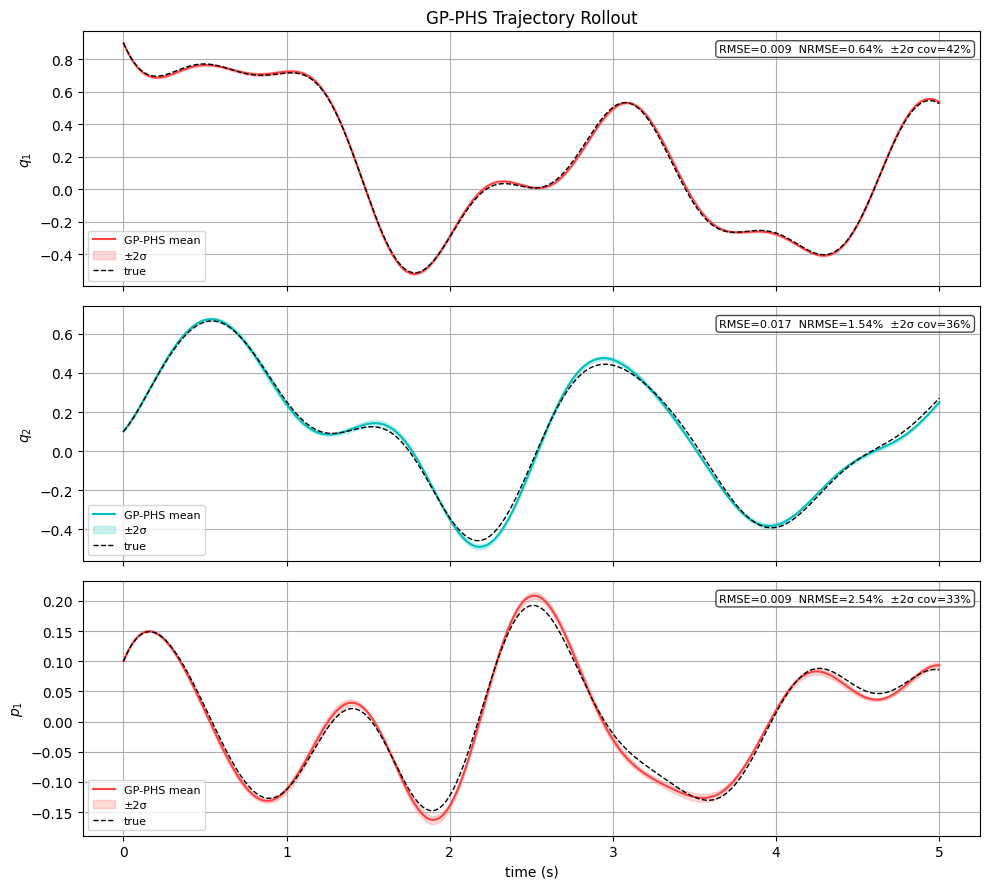

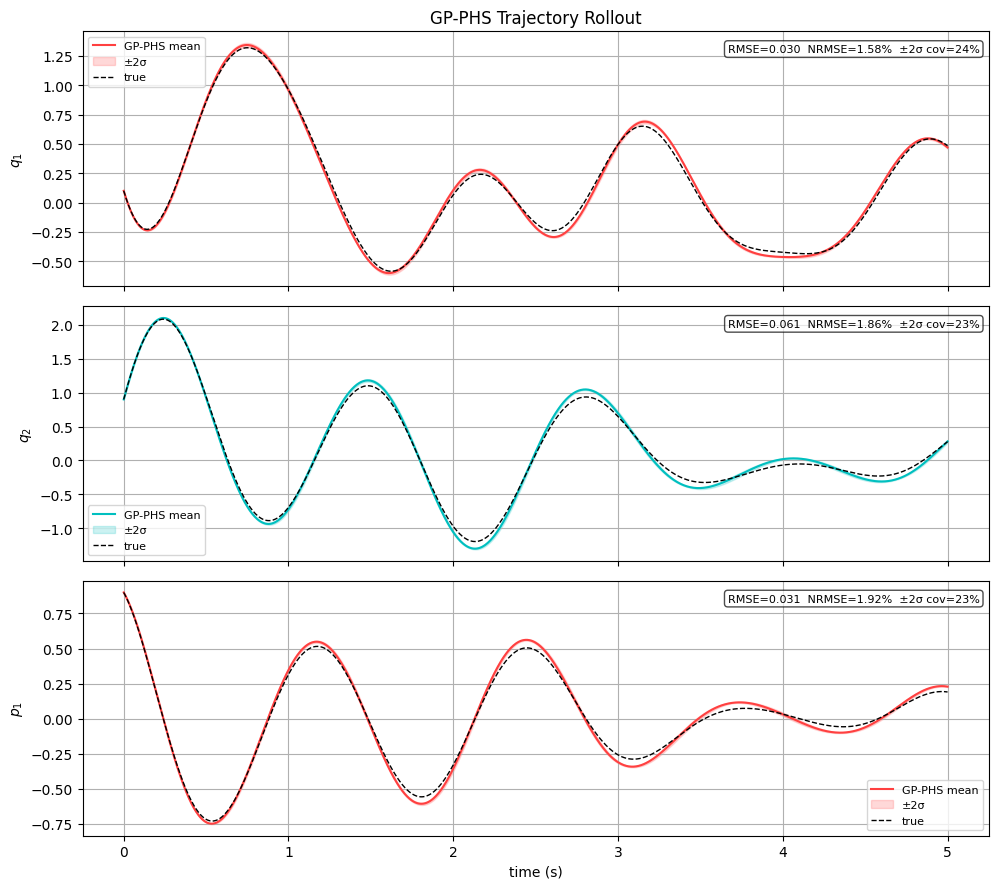

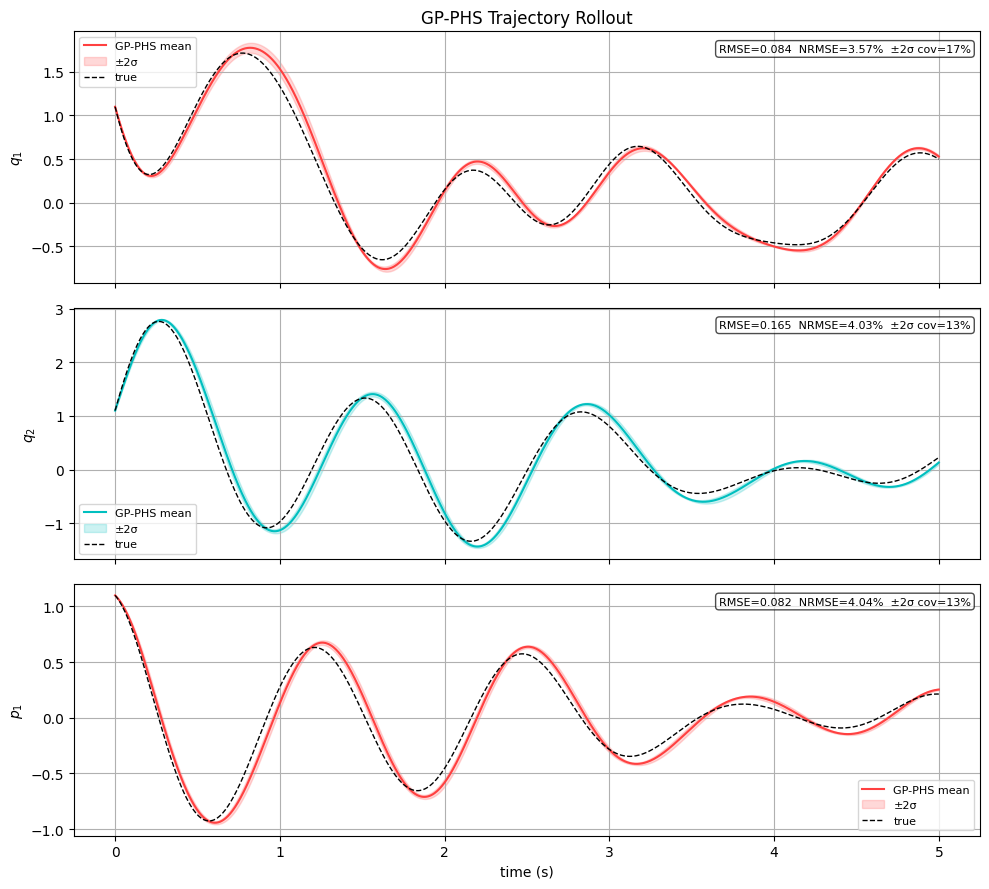

In [20]:
for i in range(len(X0_TEST)):
    plot.pltTrajectory(
        t_gp,
        mean[:, i, :],
        std=std[:, i, :],
        x_true=traj_sims[i],
        state_lbls=[r'$q_1$', r'$q_2$', r'$p_1$', r'$p_2$'],
        figname=f"traj_{i}",
    )